# Sleep-EDF preprocessing notebook for neural network training

This notebook preprocesses the **Sleep-EDF Expanded** dataset into fixed 30-second labeled epochs suitable for training a sleep staging neural network.

What it does:
- finds `*-PSG.edf` / `*-Hypnogram.edf` pairs
- reads PSG signals with **MNE**
- reads expert sleep-stage annotations from the hypnogram EDF
- trims long wake segments before sleep onset and after sleep offset
- merges Stage 3 and Stage 4 into **N3**
- drops movement / unscored epochs
- extracts 30 s windows
- optionally removes obvious artifact epochs with **YASA**
- optionally robust-z-scores each channel
- saves compressed `.npz` files plus a metadata table

Why the default channel set is EEG-only:
- Sleep-EDF has consistent 100 Hz EEG and EOG channels across the dataset
- the cassette study has submental EMG sampled at **1 Hz**, while telemetry EMG is **100 Hz**
- using only channels with consistent sampling avoids train/test modality mismatch across recordings

## 1) Install packages

Uncomment this cell if you need to install dependencies in your notebook environment.

In [1]:
%pip install -U mne yasa pyarrow pandas numpy matplotlib tqdm

  Using cached mne-1.12.0-py3-none-any.whl.metadata (16 kB)
  Using cached yasa-0.7.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached antropy-0.2.2-py3-none-any.whl.metadata (9.2 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached lspopt-1.4.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached p

## 2) Imports

In [1]:
from __future__ import annotations

import re
import json
from pathlib import Path
from dataclasses import dataclass, asdict

import mne
import yasa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

c:\Users\ryanz\anaconda3\envs\sleepnet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) Configuration

Set `DATA_ROOT` to the folder containing the Sleep-EDF files you downloaded from PhysioNet.

Expected structure can be flat or nested. The notebook will recursively search for:
- `*PSG.edf`
- matching `*Hypnogram.edf`

Examples:
- `sleep-cassette/SC4001E0-PSG.edf`
- `sleep-cassette/SC4001EC-Hypnogram.edf`
- `sleep-telemetry/ST7021J0-PSG.edf`
- `sleep-telemetry/ST7021JM-Hypnogram.edf`

In [12]:
DATA_ROOT = Path(r"C:\Users\ryanz\Documents\somneuro\sleepnet\data\sleep-edf-database-expanded-1.0.0")   # <-- change this
OUT_ROOT = Path(r"C:\Users\ryanz\Documents\somneuro\sleepnet\data\preprocessed")

# Channel selection
# Recommended default for consistency across the whole dataset:
USE_CHANNELS = ["Fpz-Cz", "Pz-Oz"]

# If you want to try EEG + EOG and your files expose a consistent EOG channel name,
# change to something like:
# USE_CHANNELS = ["EEG Fpz-Cz", "EEG Pz-Oz", "EOG horizontal"]

# Epoching / labels
EPOCH_SEC = 30
TRIM_WAKE_MIN = 30              # keep at most 30 min wake before first sleep / after last sleep
MERGE_N3_N4 = True
DROP_MOVEMENT_AND_UNSCORED = True

# Artifact rejection
RUN_YASA_ARTIFACT_REJECTION = False
YASA_ART_METHOD = "covar"       # "covar" or "std"

# Normalization
APPLY_ROBUST_ZSCORE = True      # median / IQR per channel, per recording

# Output format
SAVE_PER_RECORDING_NPZ = True
SAVE_COMBINED_DATASET = True

OUT_ROOT.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUT_ROOT.resolve())

Output folder: C:\Users\ryanz\Documents\somneuro\sleepnet\data\preprocessed


## 4) Helper functions

In [3]:
PSG_RE = re.compile(r"^(?P<base>.+)-PSG\.edf$", re.IGNORECASE)
HYP_RE = re.compile(r"^(?P<prefix>.+)-Hypnogram\.edf$", re.IGNORECASE)

ANNOT_MAP_6_STAGE = {
    "Sleep stage W": 0,   # WAKE
    "Sleep stage 1": 1,   # N1
    "Sleep stage 2": 2,   # N2
    "Sleep stage 3": 3,   # N3
    "Sleep stage 4": 3,   # N4 merged into N3
    "Sleep stage R": 4,   # REM
    "Sleep stage ?": -2,  # Unscored
    "Movement time": -1,  # Movement / artifact
}

ANNOT_MAP_7_STAGE = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
    "Sleep stage ?": -2,
    "Movement time": -1,
}

INT_TO_STAGE_5 = {
    0: "W",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM",
}

INT_TO_STAGE_6 = {
    0: "W",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "N4",
    5: "REM",
}

def extract_subject_record_id(psg_path: Path) -> str:
    return psg_path.name.replace("-PSG.edf", "")

def find_sleep_edf_pairs(root: Path) -> pd.DataFrame:
    psg_files = sorted(root.rglob("*-PSG.edf"))
    hyp_files = sorted(root.rglob("*-Hypnogram.edf"))

    hyp_index = {}
    for hyp in hyp_files:
        hyp_index[hyp.name] = hyp

    rows = []
    for psg in psg_files:
        m = PSG_RE.match(psg.name)
        if not m:
            continue
        base = m.group("base")
        hyp_candidates = list(psg.parent.glob(f"{base[:6]}*-Hypnogram.edf"))
        if len(hyp_candidates) == 1:
            hyp = hyp_candidates[0]
        else:
            # fallback: all files in same folder that share first 6 characters (e.g., SC4001 / ST7021)
            if not hyp_candidates:
                same_prefix = [h for h in hyp_files if h.parent == psg.parent and h.name[:6] == psg.name[:6]]
                if len(same_prefix) == 1:
                    hyp = same_prefix[0]
                else:
                    raise FileNotFoundError(f"Could not uniquely match hypnogram for {psg}")
            else:
                raise RuntimeError(f"Multiple hypnogram matches for {psg}: {hyp_candidates}")

        rows.append({
            "record_id": extract_subject_record_id(psg),
            "psg_path": str(psg),
            "hyp_path": str(hyp),
            "study": "SC" if psg.name.startswith("SC") else "ST" if psg.name.startswith("ST") else "UNKNOWN"
        })

    df = pd.DataFrame(rows).sort_values("record_id").reset_index(drop=True)
    return df

def trim_annotations_to_sleep_window(annot: mne.Annotations, trim_wake_min: int = 30) -> mne.Annotations:
    desc = np.array(annot.description)
    onset = np.array(annot.onset, dtype=float)

    sleep_mask = np.isin(desc, ["Sleep stage 1", "Sleep stage 2", "Sleep stage 3", "Sleep stage 4", "Sleep stage R"])
    if not sleep_mask.any():
        return annot

    first_sleep_onset = onset[sleep_mask].min()
    last_sleep_onset = onset[sleep_mask].max()

    tmin = max(0.0, first_sleep_onset - trim_wake_min * 60)
    tmax = last_sleep_onset + trim_wake_min * 60

    annot_trim = annot.copy()
    annot_trim.crop(tmin=tmin, tmax=tmax)
    return annot_trim

def choose_available_channels(raw: mne.io.BaseRaw, requested_channels: list[str]) -> list[str]:
    missing = [ch for ch in requested_channels if ch not in raw.ch_names]
    if missing:
        raise ValueError(
            f"Missing requested channels {missing}.\n"
            f"Available channels are: {raw.ch_names}"
        )
    return requested_channels

def robust_zscore_epochs(x: np.ndarray, eps: float = 1e-8) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # x shape: (n_epochs, n_channels, n_samples)
    flat = x.transpose(1, 0, 2).reshape(x.shape[1], -1)
    med = np.median(flat, axis=1, keepdims=True)
    q1 = np.percentile(flat, 25, axis=1, keepdims=True)
    q3 = np.percentile(flat, 75, axis=1, keepdims=True)
    iqr = np.maximum(q3 - q1, eps)

    x_norm = x.copy()
    for ch in range(x.shape[1]):
        x_norm[:, ch, :] = (x[:, ch, :] - med[ch, 0]) / iqr[ch, 0]
    return x_norm, med.squeeze(), iqr.squeeze()

def make_stage_name(y_int: np.ndarray, merge_n3_n4: bool = True) -> np.ndarray:
    mapping = INT_TO_STAGE_5 if merge_n3_n4 else INT_TO_STAGE_6
    return np.array([mapping[int(v)] for v in y_int], dtype=object)

@dataclass
class RecordOutput:
    record_id: str
    study: str
    psg_path: str
    hyp_path: str
    channel_names: list[str]
    sfreq: float
    n_epochs: int
    n_kept_epochs: int
    label_counts: dict
    artifact_epochs_removed: int
    npz_path: str | None = None

## 5) Preview the dataset pairs

In [4]:
pairs_df = find_sleep_edf_pairs(DATA_ROOT)
print(f"Found {len(pairs_df)} PSG/Hypnogram pairs")
display(pairs_df.head())

Found 197 PSG/Hypnogram pairs


,record_id,psg_path,hyp_path,study
0,SC4001E0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,SC
1,SC4002E0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,SC
2,SC4011E0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,SC
3,SC4012E0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,SC
4,SC4021E0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,SC


## 6) Single-record inspection

Run this once before batch processing to verify:
- channel names
- annotations
- epoch counts
- label mapping

In [7]:
example_psg = Path(pairs_df.loc[1, "psg_path"])
example_hyp = Path(pairs_df.loc[1, "hyp_path"])

raw = mne.io.read_raw_edf(example_psg, preload=True, infer_types=True, verbose="error")
annot = mne.read_annotations(example_hyp)
annot = trim_annotations_to_sleep_window(annot, trim_wake_min=TRIM_WAKE_MIN)
raw.set_annotations(annot, emit_warning=False)

print("Channels:")
print(raw.ch_names)
print("\nSampling rates by channel:")
for ch_name, sf in zip(raw.ch_names, raw._raw_extras[0]["n_samps"], strict=False):
    pass

print("\nFirst few annotations:")
display(pd.DataFrame({
    "onset_sec": annot.onset[:20],
    "duration_sec": annot.duration[:20],
    "description": annot.description[:20]
}))

Channels:
['Fpz-Cz', 'Pz-Oz', 'horizontal', 'oro-nasal', 'submental', 'rectal', 'Event marker']

Sampling rates by channel:

First few annotations:


,onset_sec,duration_sec,description
0,24270.0,1800.0,Sleep stage W
1,26070.0,90.0,Sleep stage 1
2,26160.0,510.0,Sleep stage 2
3,26670.0,270.0,Sleep stage 3
4,26940.0,1140.0,Sleep stage 4
5,28080.0,30.0,Movement time
6,28110.0,120.0,Sleep stage 3
7,28230.0,30.0,Sleep stage 4
8,28260.0,30.0,Sleep stage 3
9,28290.0,30.0,Sleep stage 4


## 7) Core preprocessing function

This function:
1. loads a PSG and matching hypnogram
2. trims long wake
3. maps annotations to 5-stage labels
4. creates 30-second epochs
5. optionally removes obvious artifact epochs using YASA
6. optionally applies robust z-scoring
7. saves the result as `.npz`

In [8]:
def preprocess_record(
    psg_path: Path,
    hyp_path: Path,
    out_dir: Path,
    use_channels: list[str],
    epoch_sec: int = 30,
    trim_wake_min: int = 30,
    merge_n3_n4: bool = True,
    drop_movement_and_unscored: bool = True,
    run_yasa_artifact_rejection: bool = False,
    yasa_art_method: str = "covar",
    apply_robust_zscore: bool = True,
    save_npz: bool = True,
) -> RecordOutput:
    record_id = extract_subject_record_id(psg_path)
    study = "SC" if psg_path.name.startswith("SC") else "ST" if psg_path.name.startswith("ST") else "UNKNOWN"

    raw = mne.io.read_raw_edf(psg_path, preload=True, infer_types=True, verbose="error")
    annot = mne.read_annotations(hyp_path)
    annot = trim_annotations_to_sleep_window(annot, trim_wake_min=trim_wake_min)
    raw.set_annotations(annot, emit_warning=False)

    keep_channels = choose_available_channels(raw, use_channels)
    raw.pick(keep_channels)

    annotation_desc_2_event_id = {
        "Sleep stage W": 1,
        "Sleep stage 1": 2,
        "Sleep stage 2": 3,
        "Sleep stage 3": 4,
        "Sleep stage 4": 5 if not merge_n3_n4 else 4,
        "Sleep stage R": 6 if not merge_n3_n4 else 5,
    }

    events, _ = mne.events_from_annotations(
        raw,
        event_id=annotation_desc_2_event_id,
        chunk_duration=float(epoch_sec),
        verbose="error",
    )

    if merge_n3_n4:
        event_id = {
            "Sleep stage W": 1,
            "Sleep stage 1": 2,
            "Sleep stage 2": 3,
            "Sleep stage 3/4": 4,
            "Sleep stage R": 5,
        }
        event_code_to_label = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
    else:
        event_id = {
            "Sleep stage W": 1,
            "Sleep stage 1": 2,
            "Sleep stage 2": 3,
            "Sleep stage 3": 4,
            "Sleep stage 4": 5,
            "Sleep stage R": 6,
        }
        event_code_to_label = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}

    tmax = epoch_sec - 1.0 / raw.info["sfreq"]
    epochs = mne.Epochs(
        raw=raw,
        events=events,
        event_id=event_id,
        tmin=0.0,
        tmax=tmax,
        baseline=None,
        preload=True,
        verbose="error",
    )

    x = epochs.get_data(units="uV").astype(np.float32)  # shape: (n_epochs, n_channels, n_samples)
    y_event = epochs.events[:, -1]
    y = np.array([event_code_to_label[int(v)] for v in y_event], dtype=np.int64)
    stage_name = make_stage_name(y, merge_n3_n4=merge_n3_n4)

    artifact_removed = 0
    if run_yasa_artifact_rejection:
        # YASA artifact rejection expects shape (n_chan, n_samples_total) or MNE Raw
        # Here we adapt it epoch-wise using the concatenated signal and the epoch-level hypno.
        x_concat = np.transpose(x, (1, 0, 2)).reshape(x.shape[1], -1)
        hyp_epoch = y.copy()  # 0=W,1=N1,2=N2,3=N3,4=REM ; matches YASA 5-stage convention
        art_epochs, _ = yasa.art_detect(
            x_concat,
            sf=raw.info["sfreq"],
            window=epoch_sec,
            hypno=hyp_epoch,
            include=(0, 1, 2, 3, 4),
            method=yasa_art_method,
            verbose=False,
        )
        art_epochs = np.asarray(art_epochs).astype(bool)
        artifact_removed = int(art_epochs.sum())
        keep = ~art_epochs
        x = x[keep]
        y = y[keep]
        stage_name = stage_name[keep]

    med = iqr = None
    if apply_robust_zscore:
        x, med, iqr = robust_zscore_epochs(x)

    label_counts = pd.Series(stage_name).value_counts().sort_index().to_dict()

    npz_path = None
    if save_npz:
        out_dir.mkdir(parents=True, exist_ok=True)
        npz_path = out_dir / f"{record_id}.npz"
        np.savez_compressed(
            npz_path,
            X=x.astype(np.float32),
            y=y.astype(np.int64),
            stage_name=stage_name.astype(str),
            channel_names=np.array(keep_channels, dtype=object),
            sfreq=np.array([raw.info["sfreq"]], dtype=np.float32),
            record_id=np.array([record_id], dtype=object),
            study=np.array([study], dtype=object),
            median_uV=np.array([] if med is None else med, dtype=np.float32),
            iqr_uV=np.array([] if iqr is None else iqr, dtype=np.float32),
        )

    return RecordOutput(
        record_id=record_id,
        study=study,
        psg_path=str(psg_path),
        hyp_path=str(hyp_path),
        channel_names=keep_channels,
        sfreq=float(raw.info["sfreq"]),
        n_epochs=int(len(epochs)),
        n_kept_epochs=int(len(y)),
        label_counts=label_counts,
        artifact_epochs_removed=int(artifact_removed),
        npz_path=None if npz_path is None else str(npz_path),
    )

## 8) Test preprocessing on one record

In [13]:
test_out = preprocess_record(
    psg_path=Path(pairs_df.loc[0, "psg_path"]),
    hyp_path=Path(pairs_df.loc[0, "hyp_path"]),
    out_dir=OUT_ROOT / "per_record",
    use_channels=USE_CHANNELS,
    epoch_sec=EPOCH_SEC,
    trim_wake_min=TRIM_WAKE_MIN,
    merge_n3_n4=MERGE_N3_N4,
    drop_movement_and_unscored=DROP_MOVEMENT_AND_UNSCORED,
    run_yasa_artifact_rejection=RUN_YASA_ARTIFACT_REJECTION,
    yasa_art_method=YASA_ART_METHOD,
    apply_robust_zscore=APPLY_ROBUST_ZSCORE,
    save_npz=SAVE_PER_RECORDING_NPZ,
)
test_out

RecordOutput(record_id='SC4001E0', study='SC', psg_path='C:\\Users\\ryanz\\Documents\\somneuro\\sleepnet\\data\\sleep-edf-database-expanded-1.0.0\\sleep-edf-database-expanded-1.0.0\\sleep-cassette\\SC4001E0-PSG.edf', hyp_path='C:\\Users\\ryanz\\Documents\\somneuro\\sleepnet\\data\\sleep-edf-database-expanded-1.0.0\\sleep-edf-database-expanded-1.0.0\\sleep-cassette\\SC4001EC-Hypnogram.edf', channel_names=['Fpz-Cz', 'Pz-Oz'], sfreq=100.0, n_epochs=836, n_kept_epochs=836, label_counts={'N1': 58, 'N2': 250, 'N3': 220, 'REM': 125, 'W': 183}, artifact_epochs_removed=0, npz_path='C:\\Users\\ryanz\\Documents\\somneuro\\sleepnet\\data\\preprocessed\\per_record\\SC4001E0.npz')

In [20]:
data = np.load(r"C:\Users\ryanz\Documents\somneuro\sleepnet\data\preprocessed\per_record\SC4001E0.npz", allow_pickle=True)

In [21]:
for key in data.files:
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

X: shape=(836, 2, 3000), dtype=float32
y: shape=(836,), dtype=int64
stage_name: shape=(836,), dtype=<U3
channel_names: shape=(2,), dtype=object
sfreq: shape=(1,), dtype=float32
record_id: shape=(1,), dtype=object
study: shape=(1,), dtype=object
median_uV: shape=(2,), dtype=float32
iqr_uV: shape=(2,), dtype=float32


In [22]:
y = data["y"]
stage_names = data["stage_name"]

print(pd.Series(stage_names).value_counts())

N2     250
N3     220
W      183
REM    125
N1      58
Name: count, dtype: int64


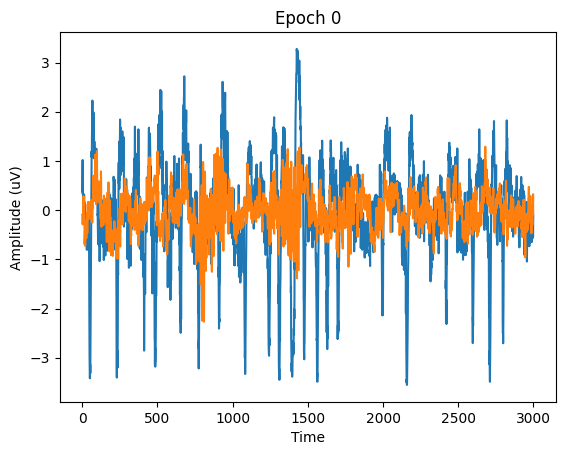

In [23]:
X = data["X"]

epoch_idx = 0
plt.plot(X[epoch_idx].T)  # transpose so time is x-axis
plt.title(f"Epoch {epoch_idx}")
plt.xlabel("Time")
plt.ylabel("Amplitude (uV)")
plt.show()

In [25]:
X.shape

(836, 2, 3000)

## 9) Batch preprocess all records

In [26]:
all_outputs = []
errors = []

for row in tqdm(pairs_df.itertuples(index=False), total=len(pairs_df)):
    try:
        result = preprocess_record(
            psg_path=Path(row.psg_path),
            hyp_path=Path(row.hyp_path),
            out_dir=OUT_ROOT / "per_record",
            use_channels=USE_CHANNELS,
            epoch_sec=EPOCH_SEC,
            trim_wake_min=TRIM_WAKE_MIN,
            merge_n3_n4=MERGE_N3_N4,
            drop_movement_and_unscored=DROP_MOVEMENT_AND_UNSCORED,
            run_yasa_artifact_rejection=RUN_YASA_ARTIFACT_REJECTION,
            yasa_art_method=YASA_ART_METHOD,
            apply_robust_zscore=APPLY_ROBUST_ZSCORE,
            save_npz=SAVE_PER_RECORDING_NPZ,
        )
        all_outputs.append(asdict(result))
    except Exception as e:
        errors.append({
            "psg_path": row.psg_path,
            "hyp_path": row.hyp_path,
            "error": repr(e),
        })

summary_df = pd.DataFrame(all_outputs)
errors_df = pd.DataFrame(errors)

display(summary_df.head())
print(f"Processed: {len(summary_df)}")
print(f"Errors:    {len(errors_df)}")
if len(errors_df):
    display(errors_df.head())

100%|██████████| 197/197 [27:21<00:00,  8.33s/it]


,record_id,study,psg_path,hyp_path,channel_names,sfreq,n_epochs,n_kept_epochs,label_counts,artifact_epochs_removed,npz_path
0,SC4001E0,SC,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,"[Fpz-Cz, Pz-Oz]",100.0,836,836,"{'N1': 58, 'N2': 250, 'N3': 220, 'REM': 125, '...",0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...
1,SC4002E0,SC,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,"[Fpz-Cz, Pz-Oz]",100.0,1115,1115,"{'N1': 59, 'N2': 373, 'N3': 297, 'REM': 215, '...",0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...
2,SC4011E0,SC,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,"[Fpz-Cz, Pz-Oz]",100.0,1087,1087,"{'N1': 109, 'N2': 562, 'N3': 105, 'REM': 170, ...",0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...
3,SC4012E0,SC,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,"[Fpz-Cz, Pz-Oz]",100.0,1149,1149,"{'N1': 92, 'N2': 660, 'N3': 96, 'REM': 176, 'W...",0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...
4,SC4021E0,SC,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,"[Fpz-Cz, Pz-Oz]",100.0,1020,1020,"{'N1': 94, 'N2': 545, 'N3': 95, 'REM': 163, 'W...",0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...


Processed: 178
Errors:    19


,psg_path,hyp_path,error
0,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,ValueError('No matching events found for Sleep...
1,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,ValueError('No matching events found for Sleep...
2,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,ValueError('No matching events found for Sleep...
3,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,ValueError('No matching events found for Sleep...
4,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,C:\Users\ryanz\Documents\somneuro\sleepnet\dat...,ValueError('No matching events found for Sleep...


## 10) Save metadata tables

In [27]:
summary_path = OUT_ROOT / "preprocessing_summary.csv"
errors_path = OUT_ROOT / "preprocessing_errors.csv"

summary_df.to_csv(summary_path, index=False)
errors_df.to_csv(errors_path, index=False)

print(summary_path.resolve())
print(errors_path.resolve())

C:\Users\ryanz\Documents\somneuro\sleepnet\data\preprocessed\preprocessing_summary.csv
C:\Users\ryanz\Documents\somneuro\sleepnet\data\preprocessed\preprocessing_errors.csv


## 11) Inspect class balance after preprocessing

,n_epochs
N1,21414
N2,80125
N3,19454
REM,30814
W,54227


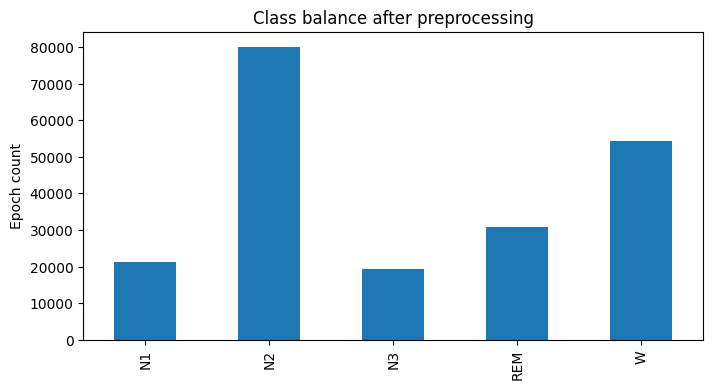

In [28]:
label_totals = {}

for d in summary_df["label_counts"]:
    if isinstance(d, str):
        d = json.loads(d.replace("'", '"'))
    for k, v in d.items():
        label_totals[k] = label_totals.get(k, 0) + int(v)

label_totals = pd.Series(label_totals).sort_index()
display(label_totals.to_frame("n_epochs"))

ax = label_totals.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("Epoch count")
ax.set_title("Class balance after preprocessing")
plt.show()

## 12) Optionally combine all records into one training file

This creates:
- `X`: shape `(N, C, T)`
- `y`: integer labels
- `record_id`: recording identifier for each epoch

This is convenient for prototyping, but for bigger experiments you may prefer loading per-record `.npz` files on the fly.

In [29]:
if SAVE_COMBINED_DATASET:
    xs, ys, records, studies = [], [], [], []
    for npz_file in tqdm(sorted((OUT_ROOT / "per_record").glob("*.npz"))):
        arr = np.load(npz_file, allow_pickle=True)
        x_i = arr["X"]
        y_i = arr["y"]
        record_id_i = str(arr["record_id"][0])
        study_i = str(arr["study"][0])

        xs.append(x_i)
        ys.append(y_i)
        records.append(np.array([record_id_i] * len(y_i), dtype=object))
        studies.append(np.array([study_i] * len(y_i), dtype=object))

    X_all = np.concatenate(xs, axis=0)
    y_all = np.concatenate(ys, axis=0)
    record_all = np.concatenate(records, axis=0)
    study_all = np.concatenate(studies, axis=0)

    combined_path = OUT_ROOT / "sleep_edf_all_epochs.npz"
    np.savez_compressed(
        combined_path,
        X=X_all.astype(np.float32),
        y=y_all.astype(np.int64),
        record_id=record_all.astype(object),
        study=study_all.astype(object),
        channel_names=np.array(USE_CHANNELS, dtype=object),
        sfreq=np.array([100.0], dtype=np.float32),
    )

    print("Combined dataset saved to:")
    print(combined_path.resolve())
    print("X shape:", X_all.shape)
    print("y shape:", y_all.shape)

100%|██████████| 178/178 [00:35<00:00,  5.01it/s]


Combined dataset saved to:
C:\Users\ryanz\Documents\somneuro\sleepnet\data\preprocessed\sleep_edf_all_epochs.npz
X shape: (206034, 2, 3000)
y shape: (206034,)


## 13) Train/validation/test split recommendation

For sleep staging, split by **recording or subject**, not by epoch, to avoid leakage.

Good options:
- leave-one-subject-out cross-validation
- subject-wise train/val/test split
- study-aware split if you want to evaluate generalization between SC and ST subsets

Do **not** randomly split epochs from the same recording across train and test.

## 14) Minimal PyTorch dataset example

In [ ]:
# from torch.utils.data import Dataset
#
# class SleepEpochDataset(Dataset):
#     def __init__(self, npz_path):
#         arr = np.load(npz_path, allow_pickle=True)
#         self.X = arr["X"].astype(np.float32)
#         self.y = arr["y"].astype(np.int64)
#
#     def __len__(self):
#         return len(self.y)
#
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

## 15) Notes

- The default pipeline uses **EEG-only** channels because they are the cleanest consistent choice across the full Sleep-EDF Expanded dataset.
- If you want to include EOG, first confirm the EOG channel name is consistent across your files.
- If you want a sequence model rather than epoch-wise classification, keep the per-record files and build sequences of adjacent epochs during training.
- If your model expects shape `(N, T, C)` instead of `(N, C, T)`, transpose before feeding the network:
  `X = np.transpose(X, (0, 2, 1))`